# Model Experimentation — Day 1

This experiment focuses on `target_aqi_day1`.

## Approach

1. Load the full 49-feature modeling dataset and create chronological train/validation/test splits.
2. Combine the training and validation sets into a single pool for feature selection, hyperparameter tuning, and model comparison.
3. Keep the test set completely untouched until the final evaluation.
4. Experiment with **Random Forest**, applying RFECV with `TimeSeriesSplit(5)` and tuning the selected feature set using time-series cross-validation.
5. Experiment with **Ridge Regression**, applying the existing preprocessing, RFECV, and alpha tuning using `TimeSeriesSplit(5)`.
6. Experiment with **XGBoost**, applying RFECV and hyperparameter tuning using `TimeSeriesSplit(5)`.
7. Experiment with **LightGBM**, applying RFECV and hyperparameter tuning using `TimeSeriesSplit(5)`.
8. Experiment with **MLP** using the feature subset selected by Ridge RFECV, manually evaluating architecture variants across the same five time-series folds.
9. Compare the five model types using their CV-averaged R², RMSE, and MAE.
10. Select the best-performing configuration for Day 1 based only on cross-validation results.
11. Retrain the winning configuration on the full train+validation pool.
12. Evaluate the final Day 1 model once on the untouched test set.
13. Record the final test metrics and selected configuration for the Day 1 experiment.

In [192]:
import random

from src.common.constants import ALL_LOG_TRANSFORM_FEATURES, ALL_TRAINING_FEATURES, TARGET_COLUMNS
from src.modeling.data_utils import load_modeling_data, split_modeling_data, preprocess_data

import shap
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV
from tensorflow.keras import layers, regularizers
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

In [137]:
df = load_modeling_data()

train_df, val_df, test_df = split_modeling_data(df)

target_label = ["target_aqi_day1"]

In [138]:
train_df_preprocess, val_df_preprocess, test_df_preprocess = preprocess_data(train_df, val_df, test_df, log_features=ALL_LOG_TRANSFORM_FEATURES, scale_features=ALL_TRAINING_FEATURES)

In [144]:
train_val_df = pd.concat(
    [train_df, val_df],
    axis=0,
).sort_values("ts").reset_index(drop=True)

train_val_df_preprocess = pd.concat(
    [train_df_preprocess, val_df_preprocess],
    axis=0,
).sort_values("ts").reset_index(drop=True)

X = train_val_df.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

X_preprocess = train_val_df_preprocess.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

y = train_val_df_preprocess[target_label].to_numpy().ravel()

X_test = test_df.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

X_test_preprocess = test_df_preprocess.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

y_test = test_df[target_label].to_numpy().ravel()

tscv = TimeSeriesSplit(n_splits=5)

In [182]:
def pred_test(model, model_type, tuned_on, X_test_req = X_test_preprocess, features = None):
    if features is None:
        y_test_pred = model.predict(X_test_req).ravel()
    else:
        y_test_pred = model.predict(X_test_req[features]).ravel()


    r2 = r2_score(y_test, y_test_pred)
    rmse = root_mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)

    print("=" * 40)
    print(f"       {model_type} (Tuned on {tuned_on} Feature Set) — Day 1")
    print("=" * 40)
    print(f"R²   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print("=" * 40)

def perform_rfecv(model, X_req = X_preprocess):
    rfecv = RFECV(
        estimator=model,
        step=1,
        scoring="r2",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
    )

    rfecv.fit(X_req, y)

    selected_features = X_req.columns[rfecv.support_]

    X_selected = X_req[selected_features]

    print(f"Selected features: {len(selected_features)} / {X_req.shape[1]}")
    print("\nSelected feature set:")
    print(list(selected_features))

    return selected_features, X_selected

def get_random_search(model):
    return RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=30,
        scoring="r2",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )

def tune_hyperparameter(X_df, model_func, search_func):
    model = model_func()

    search = search_func(model)

    search.fit(X_df, y)

    best_model = search.best_estimator_

    print("Best parameters:")
    print(search.best_params_)

    print("\nBest CV R²:")
    print(search.best_score_)

    return best_model

## Experiment 1 — Random Forest

This experiment focuses exclusively on `target_aqi_day1` using Random Forest.

The goal is to determine the best-performing Random Forest configuration for Day 1 by:

1. Using all engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` for feature selection.
3. Tuning the Random Forest hyperparameters using `TimeSeriesSplit(5)`.
4. Retraining the finalized Random Forest on the full train+validation pool.
5. Evaluating the final model once on the untouched test set.

In [142]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.75, 1.0],
}

def get_random_forest_model():
    return RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
    )

def tune_random_forest_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_random_forest_model, get_random_search)

In [145]:
best_model_random_forest = tune_random_forest_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 1.0, 'max_depth': 20}

Best CV R²:
0.8170602457945384


The tuned Random Forest achieved a cross-validation R² of **0.817** across the five time-series folds. The best configuration uses **100 trees**, `max_depth=20`, `min_samples_split=5`, `min_samples_leaf=8`, and all available features at each split (`max_features=1.0`).

In [146]:
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)

       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.8975
RMSE : 15.5528
MAE  : 11.2961


The tuned Random Forest achieved a test R² of **0.898**, with an RMSE of **15.55** and MAE of **11.30**. The model generalizes reasonably well from the time-series cross-validation results (R² **0.817**) to the untouched test set, indicating solid Day 1 prediction performance.

In [147]:
# Feature selection
random_forest = get_random_forest_model()

random_forest_rfecv_features, X_selected = perform_rfecv(random_forest, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Selected features: 28 / 49

Selected feature set:
['aqi_today', 'aqi_roll_std_7', 'aqi_change_rate', 'pm25_today', 'pm10_today', 'o3_today', 'co_today', 'no2_today', 'so2_today', 'temp_today', 'pressure_today', 'humidity_today', 'wind_spd_today

RFECV selected **28 of 49 features**, retaining the majority of the available features for the Random Forest model.

In [148]:
best_model_random_forest_rfecv = tune_random_forest_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 0.75, 'max_depth': 30}

Best CV R²:
0.8202378657390892


The tuned Random Forest achieved a cross-validation R² of **0.820** across the five time-series folds. The best configuration uses **300 trees**, `max_depth=30`, `min_samples_split=10`, `min_samples_leaf=8`, and `max_features=0.75`.

In [149]:
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)
pred_test(best_model_random_forest_rfecv, "Random Forest", "RFCEV", X_test_req=X_test, features=random_forest_rfecv_features)

       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.8975
RMSE : 15.5528
MAE  : 11.2961
       Random Forest (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.8953
RMSE : 15.7175
MAE  : 11.3097


The RFECV-based Random Forest slightly underperformed the full-feature model on the untouched test set, with R² decreasing from **0.8975 to 0.8953** and RMSE increasing from **15.5528 to 15.7175**. MAE also increased slightly from **11.2961 to 11.3097**. Overall, RFECV did not improve test performance in this case, despite reducing the feature set from **49 to 28 features**.

## Experiment 2 — Ridge Regression

This experiment focuses exclusively on `target_aqi_day1` using Ridge Regression.

The goal is to determine the best-performing Ridge Regression configuration for Day 1 by:

1. Using all engineered features except `ts`.
2. Applying the existing preprocessing approach with `log1p` transformations where applicable and `RobustScaler`.
3. Applying RFECV with `TimeSeriesSplit(5)` for feature selection.
4. Tuning the Ridge `alpha` hyperparameter using `TimeSeriesSplit(5)`.
5. Recording the mean cross-validation R², RMSE, and MAE across the five time-series folds.
6. Retraining the finalized Ridge model on the full train+validation pool.
7. Evaluating the final model once on the untouched test set.

In [150]:
param_distributions = {
    "alpha": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
        1000.0,
    ],
}

def get_ridge_model():
    return Ridge(
        random_state=42,
    )

def get_grid_search(ridge_model):
    return GridSearchCV(
        estimator=ridge_model,
        param_grid=param_distributions,
        scoring="r2",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
    )

def tune_ridge_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_ridge_model, get_grid_search)

In [151]:
best_model_ridge_regression = tune_ridge_hyperparameter(X_preprocess)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters:
{'alpha': 10.0}

Best CV R²:
0.8310273399896456


Using the full feature set, Ridge Regression achieved a cross-validation R² of **0.8310** across the five time-series folds. The best-performing regularization strength was **alpha = 10.0**.

In [152]:
pred_test(best_model_ridge_regression, "Ridge Regression", "Full")

       Ridge Regression (Tuned on Full Feature Set) — Day 1
R²   : 0.8895
RMSE : 16.1521
MAE  : 12.2036


The tuned Ridge Regression achieved a test R² of **0.8895**, with an RMSE of **16.1521** and MAE of **12.2036** on the untouched test set. This indicates solid Day 1 generalization, with Ridge Regression outperforming the tuned Random Forest on the same test set.

In [153]:
ridge_regression = get_ridge_model()

ridge_regression_rfecv_features, X_selected = perform_rfecv(ridge_regression)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 fe

RFECV retained **11 out of 49 features**, indicating that Ridge Regression can achieve comparable predictive performance using a substantially reduced feature set. The selected features primarily capture current, lagged, and rolling pollutant measurements alongside current AQI.

In [154]:
best_model_ridge_regression_rfecv = tune_ridge_hyperparameter(X_selected)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters:
{'alpha': 10.0}

Best CV R²:
0.8358559467058473


After RFECV, the tuned Ridge Regression achieved a cross-validation R² of **0.8359** using **alpha = 10.0**. The optimal regularization strength remained unchanged across the reduced **11-feature set**.

In [155]:
pred_test(best_model_ridge_regression, "Ridge Regression", "Full")
pred_test(best_model_ridge_regression_rfecv, "Ridge Regression", "RFCEV", features=ridge_regression_rfecv_features)

       Ridge Regression (Tuned on Full Feature Set) — Day 1
R²   : 0.8895
RMSE : 16.1521
MAE  : 12.2036
       Ridge Regression (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.8887
RMSE : 16.2085
MAE  : 12.2835


RFECV produced nearly identical Ridge Regression performance on the untouched test set, with R² decreasing slightly from **0.8895 to 0.8887**, RMSE increasing from **16.1521 to 16.2085**, and MAE increasing from **12.2036 to 12.2835**. This indicates that the reduced **11-feature set** retains nearly all of the predictive performance of the full **49-feature set**.

In [156]:
pred_test(best_model_ridge_regression, "Ridge Regression", "Full")
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)

       Ridge Regression (Tuned on Full Feature Set) — Day 1
R²   : 0.8895
RMSE : 16.1521
MAE  : 12.2036
       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.8975
RMSE : 15.5528
MAE  : 11.2961


On the full feature set, Random Forest outperformed Ridge Regression for Day 1 prediction. Random Forest achieved a higher test R² of **0.8975** compared with **0.8895**, while also achieving lower RMSE (**15.5528 vs. 16.1521**) and MAE (**11.2961 vs. 12.2036**). This indicates that Random Forest provided better generalization and more accurate Day 1 predictions on the full feature set.

## Experiment 3 — XGBoost

This experiment focuses exclusively on `target_aqi_day1` using XGBoost.

The goal is to determine the best-performing XGBoost configuration for Day 1 by:

1. Using all 49 engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` and `scoring="r2"` for feature selection.
3. Taking the CV-selected feature subset for subsequent model tuning.
4. Tuning the main XGBoost hyperparameters using `GridSearchCV` or `RandomizedSearchCV` with the same `TimeSeriesSplit(5)`, including:
   - `n_estimators`
   - `max_depth`
   - `learning_rate`
   - `min_child_weight`
   - `subsample`
   - `colsample_bytree`
   - `reg_alpha`
   - `reg_lambda`
5. Recording the mean cross-validation R², RMSE, and MAE across all five time-series folds.
6. Using early stopping only if it can be implemented without contaminating the cross-validation evaluation; otherwise, relying on the CV-selected `n_estimators` and regularization parameters.
7. Retraining the finalized XGBoost model on the full train+validation pool.
8. Evaluating the final model once on the untouched test set.

In [157]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10, None],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.1, 1.0, 10.0],
}


def get_xgboost_model():
    return XGBRegressor(
        random_state=42,
        n_jobs=-1,
    )

def tune_xgboost_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_xgboost_model, get_random_search)

In [158]:
best_model_xgboost = tune_xgboost_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Best CV R²:
0.8204153763731556


Using the full feature set, the tuned XGBoost model achieved a cross-validation R² of **0.8204** across the five time-series folds. The best configuration used **100 estimators**, a **learning rate of 0.03**, **max depth of 3**, **min child weight of 5**, and **subsample/feature sampling of 0.6/0.8**. The results indicate that a shallow, conservatively regularized model provided the strongest cross-validation performance among the tested configurations.

In [159]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.8752
RMSE : 17.1624
MAE  : 12.3584


The tuned XGBoost model using the full feature set achieved a **test R² of 0.8752**, with an **RMSE of 17.1624** and **MAE of 12.3584**. The results demonstrate solid predictive performance on the untouched test set, although XGBoost performed worse than both Ridge Regression and Random Forest for Day 1 prediction.

In [160]:
xgboost = get_xgboost_model()

xgboost_rfecv_features, X_selected = perform_rfecv(xgboost, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 fe

RFECV reduced the XGBoost feature set from **49 to 18 features**, indicating that a substantial portion of the engineered features could be removed while retaining the most relevant predictive information for Day 1. The selected features primarily capture current pollutant levels, recent lagged measurements, and short-term rolling statistics.

In [161]:
best_model_xgboost_rfecv = tune_xgboost_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': None, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

Best CV R²:
0.8298371539834957


Using the **18 RFECV-selected features**, the tuned XGBoost model achieved a cross-validation R² of **0.8298** across the five time-series folds. The best configuration used **500 estimators**, a **learning rate of 0.01**, **min child weight of 1**, **subsample/feature sampling of 0.6/0.6**, **reg_alpha of 0.1**, and **reg_lambda of 1.0**. CV performance improved from **0.8204 to 0.8298** compared with the full feature set, indicating that removing redundant features improved XGBoost's cross-validation performance for Day 1.

In [162]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)
pred_test(best_model_xgboost_rfecv, "XGBoost", "RFCEV", X_test_req=X_test, features=xgboost_rfecv_features)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.8752
RMSE : 17.1624
MAE  : 12.3584
       XGBoost (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.8978
RMSE : 15.5342
MAE  : 11.1231


The XGBoost model using the **RFECV-selected feature set** outperformed the full-feature model on the untouched test set. The RFECV-based model achieved a higher R² of **0.8978** compared with **0.8752**, while also achieving lower RMSE (**15.5342 vs. 17.1624**) and MAE (**11.1231 vs. 12.3584**). This indicates that RFECV improved XGBoost's Day 1 test performance by removing redundant features while retaining the most predictive information.

In [163]:
pred_test(best_model_xgboost_rfecv, "XGBoost", "RFCEV", X_test_req=X_test, features=xgboost_rfecv_features)
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)

       XGBoost (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.8978
RMSE : 15.5342
MAE  : 11.1231
       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.8975
RMSE : 15.5528
MAE  : 11.2961


On the **untouched Day 1 test set**, XGBoost using the RFECV-selected feature set slightly outperformed the full-feature Random Forest model. XGBoost achieved a higher R² of **0.8978** compared with **0.8975**, while also achieving lower RMSE (**15.5342 vs. 15.5528**) and MAE (**11.1231 vs. 11.2961**). Overall, the RFECV-based XGBoost model provided slightly better Day 1 predictive performance than the full-feature Random Forest.

## Experiment 4 — LightGBM

This experiment focuses exclusively on `target_aqi_day1` using LightGBM.

The goal is to determine the best-performing LightGBM configuration for Day 1 by:

1. Using all 49 engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` and `scoring="r2"` for feature selection.
3. Taking the CV-selected feature subset for subsequent model tuning.
4. Tuning the main LightGBM hyperparameters using `GridSearchCV` or `RandomizedSearchCV` with the same `TimeSeriesSplit(5)`, including:
   - `n_estimators`
   - `num_leaves`
   - `max_depth`
   - `learning_rate`
   - `min_child_samples`
   - `subsample`
   - `colsample_bytree`
   - `reg_alpha`
   - `reg_lambda`
5. Recording the mean cross-validation R², RMSE, and MAE across all five time-series folds.
6. Keeping the model configuration reasonably constrained due to the relatively small dataset, prioritizing regularization over an excessively large hyperparameter search.
7. Retraining the finalized LightGBM model on the full train+validation pool.
8. Evaluating the final model once on the untouched test set.

In [164]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "num_leaves": [15, 31, 50, 75],
    "max_depth": [-1, 3, 5, 7, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.1, 1.0, 10.0],
}


def get_lightgbm_model():
    return LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )


def tune_lightgbm_hyperparameter(X_df):
    return tune_hyperparameter(
        X_df,
        get_lightgbm_model,
        get_random_search,
    )

In [165]:
best_model_lightbgm = tune_lightgbm_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'num_leaves': 15, 'n_estimators': 100, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 1.0}

Best CV R²:
0.8045297577273043


The tuned LightGBM model achieved a cross-validation R² of **0.8045** across the five time-series folds. The best configuration used **100 estimators**, a **learning rate of 0.03**, **15 leaves**, `min_child_samples=10`, `reg_alpha=0.01`, and `reg_lambda=1.0`. The results indicate that a relatively constrained LightGBM configuration provided the strongest cross-validation performance among the tested configurations.

In [166]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.8839
RMSE : 16.5549
MAE  : 11.9969


The tuned LightGBM model using the full feature set achieved a **test R² of 0.8839**, with an **RMSE of 16.5549** and **MAE of 11.9969** on the untouched test set. The model demonstrated strong predictive performance, although it underperformed both Ridge Regression and Random Forest for Day 1 prediction.

In [167]:
lightbgm = get_lightgbm_model()

lightbgm_rfecv_features, X_selected = perform_rfecv(lightbgm, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Selected features: 47 / 49

Selected feature set:
['aqi_today', 'aqi_lag_1', 'aqi_lag_2', 'aqi_lag_3', 'aqi_roll_mean_3', 'aqi_roll_mean_7', 'aqi_roll_std_3', 'aqi_roll_std_7', 'aqi_change_rate', 'pm25_today', 'pm10_today', 'o3_today', 'co_today', 'no2_today', 'so2_today', 'temp_today', 'pressure_today', 'humidity_today', 'wind_spd_today', 'dew_pt_today', 'pm25_lag_1', 'pm10_lag_1', 'o3_lag_1', 'pm25_lag_2', 'pm10_lag_2', 'o3_lag_2', 'pm25_lag_3', 'pm10_lag_3', 'o3_lag_3', 'temp_lag_1', 'pressure_lag_1', 'humidity_lag_1', 'wind_spd_lag_1', 'dew_pt_lag_1', 'pm25_roll_mean_3', 'pm25_roll_mean_7', 'pm10_roll_mean_3', 'pm10_roll_mean_7', 'o3_roll_mean_3', 'o3_roll_mean_7', 'pm25_roll_std_3', 'pm25_roll_std_7', 'pm10_roll_std_3', 'pm10_roll_std_7', 'o3_roll_std_3', 'o3_roll_std_7', 'day_of_week']


RFECV reduced the LightGBM feature set from **49 to 47 features**, indicating that only a small portion of the engineered features were removed for Day 1 prediction. The selected feature set retained most of the current pollutant, AQI, weather, lag, and rolling statistical features.

In [168]:
best_model_lightbgm_rfecv = tune_lightgbm_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'num_leaves': 15, 'n_estimators': 100, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 1.0}

Best CV R²:
0.8057180413131928


Using the **47 RFECV-selected features**, the tuned LightGBM model achieved a cross-validation R² of **0.8057** across the five time-series folds. The best hyperparameter configuration remained unchanged from the full-feature experiment, indicating that the same model configuration provided the strongest CV performance after feature selection.

In [169]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)
pred_test(best_model_lightbgm_rfecv, "LightBGM", "RFCEV", X_test_req=X_test, features=lightbgm_rfecv_features)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.8839
RMSE : 16.5549
MAE  : 11.9969
       LightBGM (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.8839
RMSE : 16.5549
MAE  : 11.9969


The RFECV-based LightGBM model achieved the **same test performance** as the full-feature model on the untouched test set, with an R² of **0.8839**, RMSE of **16.5549**, and MAE of **11.9969**. This indicates that removing the two features identified by RFECV had no measurable effect on LightGBM's Day 1 test performance.

In [170]:
pred_test(best_model_lightbgm_rfecv, "LightBGM", "RFCEV", X_test_req=X_test, features=lightbgm_rfecv_features)
pred_test(best_model_xgboost_rfecv, "XGBoost", "RFCEV", X_test_req=X_test, features=xgboost_rfecv_features)

       LightBGM (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.8839
RMSE : 16.5549
MAE  : 11.9969
       XGBoost (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.8978
RMSE : 15.5342
MAE  : 11.1231


On the **RFECV-selected feature set**, XGBoost outperformed LightGBM for Day 1 prediction. XGBoost achieved a higher test R² of **0.8978** compared with **0.8839**, while also achieving lower RMSE (**15.5342 vs. 16.5549**) and MAE (**11.1231 vs. 11.9969**). Overall, XGBoost provided better Day 1 predictive performance than LightGBM.

## Experiment 5 — MLP with Fixed Architecture (Full Feature Set)

This experiment focuses exclusively on `target_aqi_day1` using a Multi-Layer Perceptron (MLP).

The goal is to evaluate a fixed MLP configuration for Day 1 using the full engineered feature set by:

1. Using all engineered features except `ts` and the target columns.
2. Using the existing chronological train, validation, and test split.
3. Applying the existing preprocessing pipeline to the feature data.
4. Using a fixed MLP architecture with:

   * 64-unit hidden layer with ReLU activation.
   * 32-unit hidden layer with ReLU activation.
   * L2 regularization on both hidden layers.
   * Dropout of 0.1 after each hidden layer.
   * Linear output layer for regression.
5. Using the Adam optimizer with a learning rate of `1e-3`.
6. Using MSE as the training loss.
7. Training for up to 500 epochs with batch size 32.
8. Applying early stopping based on validation loss (`val_loss`) with patience of 15 epochs and restoring the best model weights.
9. Evaluating the trained model on the untouched test set using R², RMSE, and MAE.


In [171]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

X_test_preprocess_mlp = test_df_preprocess[ALL_TRAINING_FEATURES]

In [172]:
def get_mlp_model(input_dim):
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(
                64,
                activation="relu",
                kernel_regularizer=regularizers.l2(1e-4),
            ),
            layers.Dropout(0.1),
            layers.Dense(
                32,
                activation="relu",
                kernel_regularizer=regularizers.l2(1e-4),
            ),
            layers.Dropout(0.1),
            layers.Dense(1, activation="linear"),
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="mse",
    )

    return model


def get_mlp_data(train_df, val_df, features=None):
    if features is None:
        features = ALL_TRAINING_FEATURES

    X_train = train_df[features]
    y_train = train_df[target_label]

    X_val = val_df[features]
    y_val = val_df[target_label]

    return X_train, y_train, X_val, y_val


def train_mlp_model(
    model,
    train_df,
    val_df,
    features=None,
):
    X_train, y_train, X_val, y_val = get_mlp_data(
        train_df,
        val_df,
        features=features,
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
    )

    model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=500,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=1,
    )

    return model

In [173]:
mlp_model = get_mlp_model(49)

mlp_model = train_mlp_model(mlp_model, train_df_preprocess, val_df_preprocess)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 25379.0801 - val_loss: 24498.5254
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23513.8496 - val_loss: 22133.1953
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19100.1328 - val_loss: 17126.5996
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12400.3105 - val_loss: 10546.4697
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7277.1670 - val_loss: 6045.2861
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5258.8643 - val_loss: 4387.9790
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4295.9409 - val_loss: 3708.9272
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3641.4011 - val_loss: 3141.1316
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3151.1885 - val_loss: 2676.7283
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2511.0632 - val_loss: 2234.2556
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2206.2144 - val_loss

The MLP’s validation loss reached a minimum of **256.62 MSE at epoch 146**, corresponding to a validation RMSE of approximately **16.02 AQI points**.

In [174]:
pred_test(mlp_model, "MLP", "Full", X_test_req=X_test_preprocess_mlp)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
       MLP (Tuned on Full Feature Set) — Day 1
R²   : 0.8780
RMSE : 16.9669
MAE  : 11.9176


The MLP achieved a test R² of **0.8780**, with an RMSE of **16.9669** and MAE of **11.9176** AQI points on the untouched test set.

In [176]:
mlp_model_random_forest_rfecv = get_mlp_model(len(random_forest_rfecv_features))

mlp_model_random_forest_rfecv = train_mlp_model(mlp_model_random_forest_rfecv, train_df_preprocess, val_df_preprocess, features=random_forest_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 25513.4043 - val_loss: 24625.6465
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24103.5000 - val_loss: 22565.7305
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 20521.5469 - val_loss: 17900.9902
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13897.8320 - val_loss: 10863.6641
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7195.8379 - val_loss: 5444.3926
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4169.0020 - val_loss: 3650.9036
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3119.1030 - val_loss: 3040.5940
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2821.6929 - val_loss: 2550.7710
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2379.5107 - val_loss: 2112.1199
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2031.1705 - val_loss: 1758.7264
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1810.1124 - val_loss

The MLP’s validation loss reached a minimum of **224.83 MSE at epoch 134**, corresponding to a validation RMSE of approximately **14.99 AQI points** on the RFECV-selected feature set from Random Forest.

In [181]:
pred_test(mlp_model, "MLP", "Full", X_test_req=X_test_preprocess_mlp)
pred_test(mlp_model_random_forest_rfecv, "MLP", "Random Forest RFECV", X_test_req=X_test_preprocess_mlp, features=random_forest_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Full Feature Set) — Day 1
R²   : 0.8780
RMSE : 16.9669
MAE  : 11.9176
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Random Forest RFECV Feature Set) — Day 1
R²   : 0.8833
RMSE : 16.5940
MAE  : 12.3621


The MLP using the **Random Forest RFECV-selected feature set** slightly outperformed the full-feature MLP on the untouched test set. R² improved from **0.8780 to 0.8833**, while RMSE decreased from **16.9669 to 16.5940**. However, MAE increased from **11.9176 to 12.3621**, indicating mixed improvement after feature selection.

In [183]:
mlp_model_ridge_regression_rfecv = get_mlp_model(len(ridge_regression_rfecv_features))

mlp_model_ridge_regression_rfecv = train_mlp_model(mlp_model_ridge_regression_rfecv, train_df_preprocess, val_df_preprocess, features=ridge_regression_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 25727.4121 - val_loss: 25027.6133
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24866.4297 - val_loss: 24004.8066
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22975.6016 - val_loss: 21734.6914
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19254.2266 - val_loss: 17668.7656
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13881.6992 - val_loss: 12446.3916
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8953.8350 - val_loss: 8232.3350
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6761.2002 - val_loss: 6225.7681
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5857.8335 - val_loss: 5399.0063
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5298.8164 - val_loss: 4841.0894
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4775.2637 - val_loss: 4296.7856
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4287.8984 - val_lo

The MLP’s validation loss reached a minimum of **172.86 MSE at epoch 174**, corresponding to a validation RMSE of approximately **13.15 AQI points**.

In [184]:
pred_test(mlp_model_random_forest_rfecv, "MLP", "Random Forest RFECV", X_test_req=X_test_preprocess_mlp, features=random_forest_rfecv_features)
pred_test(mlp_model_ridge_regression_rfecv, "MLP", "Ridge Regression RFECV", X_test_req=X_test_preprocess_mlp, features=ridge_regression_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
       MLP (Tuned on Random Forest RFECV Feature Set) — Day 1
R²   : 0.8833
RMSE : 16.5940
MAE  : 12.3621
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
       MLP (Tuned on Ridge Regression RFECV Feature Set) — Day 1
R²   : 0.8934
RMSE : 15.8617
MAE  : 11.7250


The MLP using the **Ridge Regression RFECV-selected feature set** outperformed the MLP using the Random Forest RFECV feature set on the untouched test set. R² improved from **0.8833 to 0.8934**, while RMSE decreased from **16.5940 to 15.8617** and MAE decreased from **12.3621 to 11.7250**. This indicates that the Ridge-selected features provided better predictive performance for the MLP.

In [185]:
mlp_model_xgboost_rfecv = get_mlp_model(len(xgboost_rfecv_features))

mlp_model_xgboost_rfecv = train_mlp_model(mlp_model_xgboost_rfecv, train_df_preprocess, val_df_preprocess, features=xgboost_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 25513.7988 - val_loss: 24661.8418
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24352.9785 - val_loss: 23039.2227
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 21578.7539 - val_loss: 19420.3906
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16263.8818 - val_loss: 13568.6719
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9849.0967 - val_loss: 7728.6719
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5954.2310 - val_loss: 4553.0728
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4356.5259 - val_loss: 3390.6204
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3685.1807 - val_loss: 2912.1399
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3141.8396 - val_loss: 2487.5483
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2760.9834 - val_loss: 2119.6594
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2319.3770 - val_loss

The MLP’s validation loss reached a minimum of **193.24 MSE at epoch 112**, corresponding to a validation RMSE of approximately **13.90 AQI points**.

In [186]:
pred_test(mlp_model_ridge_regression_rfecv, "MLP", "Ridge Regression RFECV", X_test_req=X_test_preprocess_mlp, features=ridge_regression_rfecv_features)
pred_test(mlp_model_xgboost_rfecv, "MLP", "XGBoost RFECV", X_test_req=X_test_preprocess_mlp, features=xgboost_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Ridge Regression RFECV Feature Set) — Day 1
R²   : 0.8934
RMSE : 15.8617
MAE  : 11.7250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
       MLP (Tuned on XGBoost RFECV Feature Set) — Day 1
R²   : 0.8894
RMSE : 16.1580
MAE  : 11.6488


The MLP using the **Ridge Regression RFECV feature set** outperformed the MLP using the **XGBoost RFECV feature set** on the untouched test set. R² improved from **0.8894 to 0.8934**, while RMSE decreased from **16.1580 to 15.8617**. However, MAE increased slightly from **11.6488 to 11.7250**.

In [187]:
mlp_model_lightbgm_rfecv = get_mlp_model(len(lightbgm_rfecv_features))

mlp_model_lightbgm_rfecv = train_mlp_model(mlp_model_lightbgm_rfecv, train_df_preprocess, val_df_preprocess, features=lightbgm_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 25430.0762 - val_loss: 24375.5215
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23308.4902 - val_loss: 21713.6582
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18457.5938 - val_loss: 16180.2510
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11439.4922 - val_loss: 9524.9170
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6780.1187 - val_loss: 5722.8940
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5300.7441 - val_loss: 4427.8447
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4293.6348 - val_loss: 3702.3689
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3549.8433 - val_loss: 3102.1709
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3033.3416 - val_loss: 2678.8196
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2573.7559 - val_loss: 2268.2319
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2170.3772 - val_loss:

The MLP’s validation loss reached a minimum of **253.47 MSE at epoch 117**, corresponding to a validation RMSE of approximately **15.92 AQI points**.

In [188]:
pred_test(mlp_model_ridge_regression_rfecv, "MLP", "Ridge Regression RFECV", X_test_req=X_test_preprocess_mlp, features=ridge_regression_rfecv_features)
pred_test(mlp_model_lightbgm_rfecv, "MLP", "LightBGM RFECV", X_test_req=X_test_preprocess_mlp, features=lightbgm_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Ridge Regression RFECV Feature Set) — Day 1
R²   : 0.8934
RMSE : 15.8617
MAE  : 11.7250
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
       MLP (Tuned on LightBGM RFECV Feature Set) — Day 1
R²   : 0.8710
RMSE : 17.4497
MAE  : 12.7043


The MLP using the **Ridge Regression RFECV feature set** outperformed the MLP using the **LightGBM RFECV feature set** on the untouched test set. R² improved from **0.8710 to 0.8934**, while RMSE decreased from **17.4497 to 15.8617** and MAE decreased from **12.7043 to 11.7250**.

In [191]:
pred_test(best_model_xgboost_rfecv, "XGBoost", "RFCEV", X_test_req=X_test, features=xgboost_rfecv_features)
pred_test(mlp_model_ridge_regression_rfecv, "MLP", "Ridge Regression RFECV", X_test_req=X_test_preprocess_mlp, features=ridge_regression_rfecv_features)

       XGBoost (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.8978
RMSE : 15.5342
MAE  : 11.1231
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Ridge Regression RFECV Feature Set) — Day 1
R²   : 0.8934
RMSE : 15.8617
MAE  : 11.7250


The tuned XGBoost model using the **RFECV-selected feature set** outperformed the MLP using the **Ridge Regression RFECV feature set** on the untouched test set. XGBoost achieved a higher R² of **0.8978** compared with **0.8934**, while also achieving lower RMSE (**15.5342 vs. 15.8617**) and MAE (**11.1231 vs. 11.7250**).

## Experiment 6 — SHAP Explainability for the Final Model

This experiment focuses on interpreting the final winning model for `target_aqi_day1` using SHAP.

The goal is to identify and visualize the features that have the greatest influence on the model's predictions by:

1. Using the final selected model and its corresponding feature set.
2. Applying SHAP to explain the model's Day 1 predictions.
3. Analyzing global feature importance using SHAP values.
4. Visualizing how individual features influence predicted AQI.
5. Using SHAP explanations to improve the interpretability of the final model.

In [197]:
def get_shap(features, model):
    # Prepare the same data used by XGBoost
    X_train = train_df[features]
    X_val = val_df[features]

    X_train = X_train.to_numpy(dtype=np.float32)
    X_val = X_val.to_numpy(dtype=np.float32)

    # SHAP TreeExplainer for XGBoost
    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_val)

    # Global feature importance
    shap.summary_plot(
        shap_values,
        X_val,
        feature_names=features
    )

    # Mean absolute SHAP feature importance
    shap.summary_plot(
        shap_values,
        X_val,
        feature_names=features,
        plot_type="bar"
    )

    # Explain a single prediction
    sample_index = 0

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[sample_index],
            base_values=explainer.expected_value,
            data=X_val[sample_index],
            feature_names=features
        )
    )

C:\Users\Lucky\AppData\Local\Temp\ipykernel_4920\157152556.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


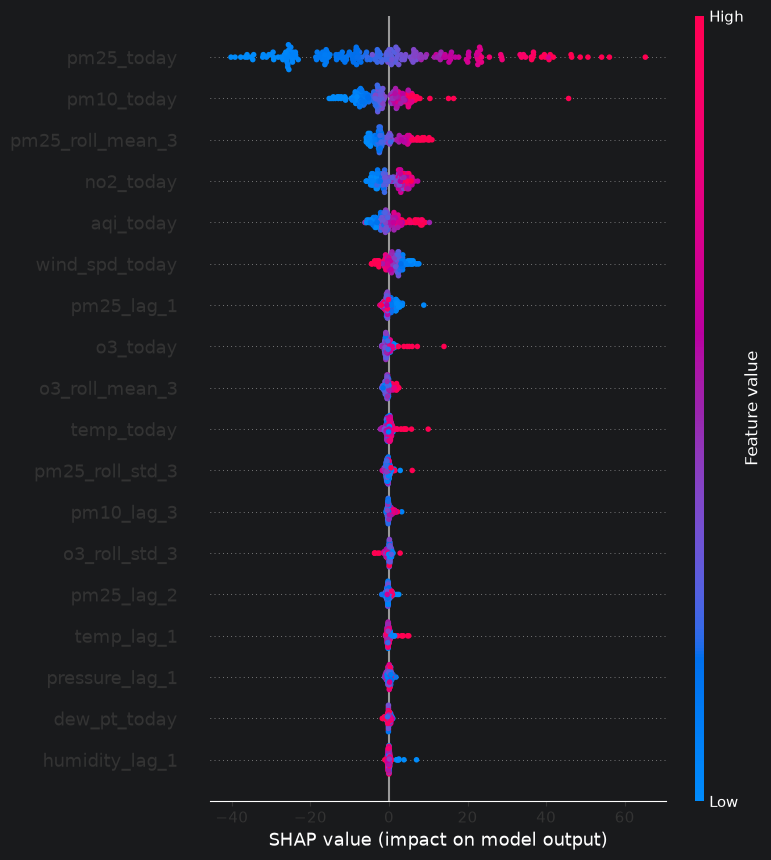

C:\Users\Lucky\AppData\Local\Temp\ipykernel_4920\157152556.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


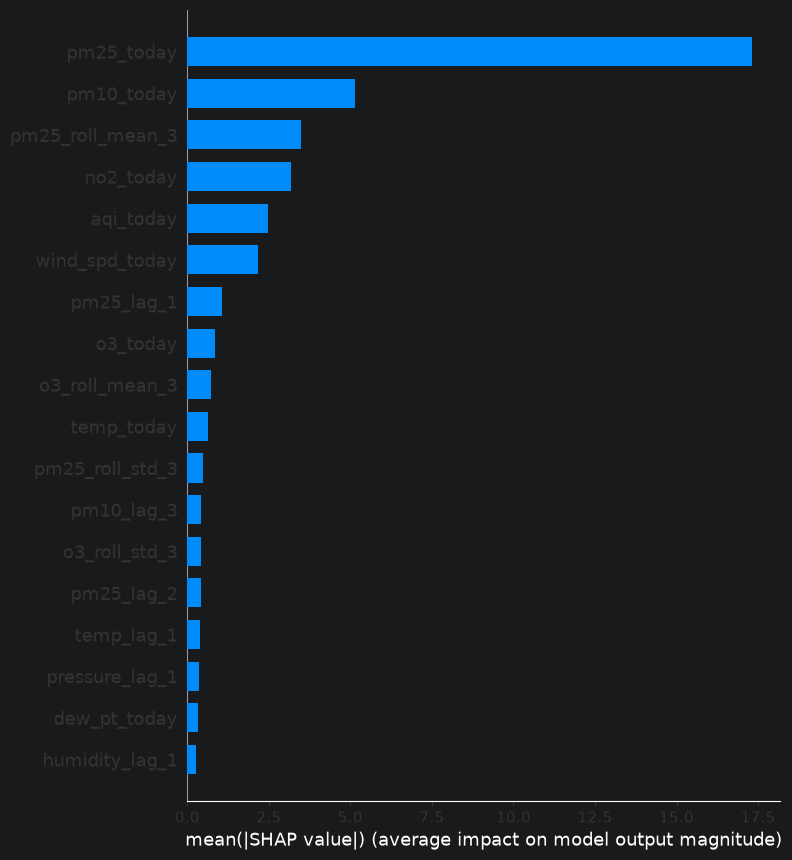

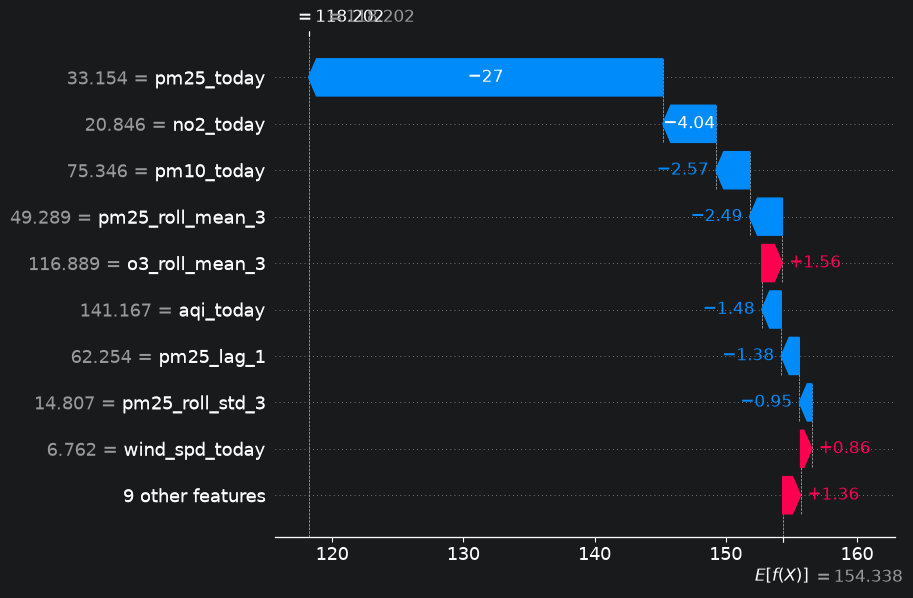

In [198]:
get_shap(xgboost_rfecv_features, best_model_xgboost_rfecv)

`pm25_today` was the most influential feature, with high PM2.5, PM10, NO₂, rolling PM2.5, and AQI values generally increasing predictions, while higher wind speed reduced them. For the analyzed instance, low `pm25_today` was the largest contributor to the prediction decrease.